# 03 - Final Result


## Executive Summary

- Phase 4 clean is the honest decontaminated baseline after removing duplicated unit columns.
- Phase 5 physics adds generalizable interaction features rather than airport-specific hacks.
- Test-set lift is mixed: `KATL -0.0076`, `KBOS +0.0096` PR-AUC.
- LORO robustness improves consistently across every evaluated airport.
- The most influential Phase 5 additions are `dew_depression_x_hour_sin`, `dew_depression_min_6h`, and `pressure_drop_x_wind`.


In [1]:
import pandas as pd
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
FIG = ROOT / 'reports' / 'figures'

test_df = pd.read_csv(FIG / 'phase4_vs_phase5_test_pr_auc.csv')
loro_df = pd.read_csv(FIG / 'phase4_vs_phase5_loro_pr_auc.csv')
physics_df = pd.read_csv(FIG / 'phase5_physics_feature_importance.csv')
test_df, loro_df, physics_df.head()


## Unseen Test Airports


In [2]:
test_df


airport,phase4_clean_pr_auc,phase5_physics_pr_auc,delta
KATL,0.727,0.719,-0.008
KBOS,0.630,0.640,0.010


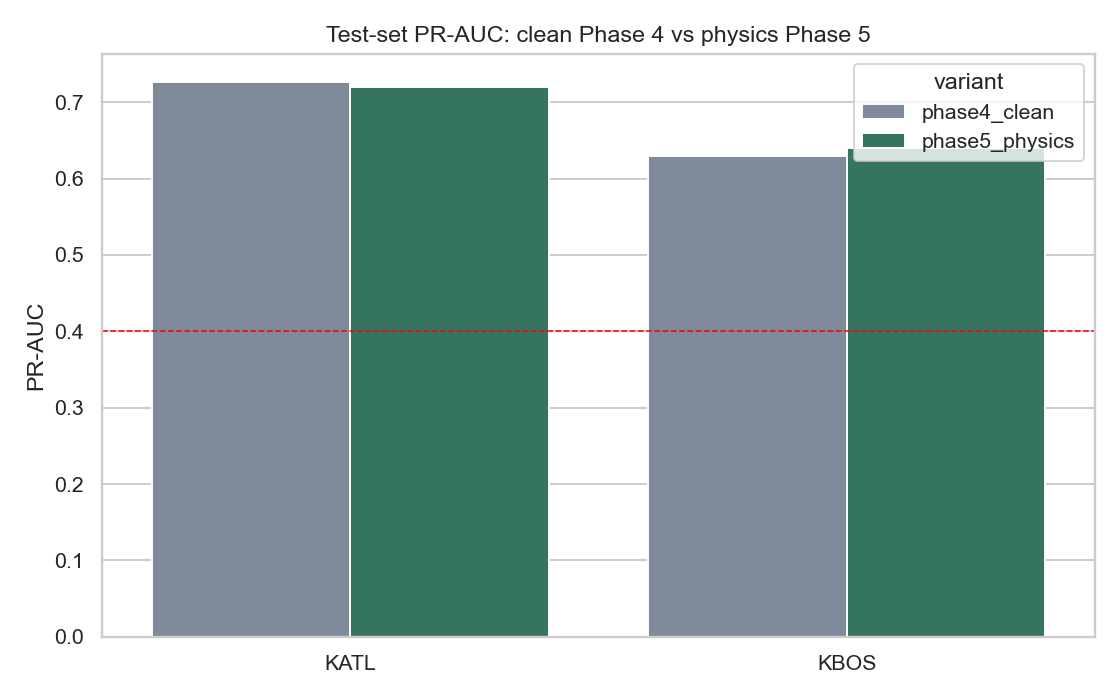

In [3]:
# Saved comparison figure
from IPython.display import Image
Image(filename=str(FIG / 'phase4_vs_phase5_test_pr_auc.png'))


## LORO Domain Robustness


In [4]:
loro_df


airport,direction,phase4_clean_pr_auc,phase5_physics_pr_auc,delta
KATL,coastal_to_inland,0.723,0.726,0.003
KBOS,inland_to_coastal,0.643,0.647,0.003
KDEN,coastal_to_inland,0.614,0.620,0.006
KDFW,coastal_to_inland,0.454,0.460,0.006
KSFO,inland_to_coastal,0.430,0.436,0.006


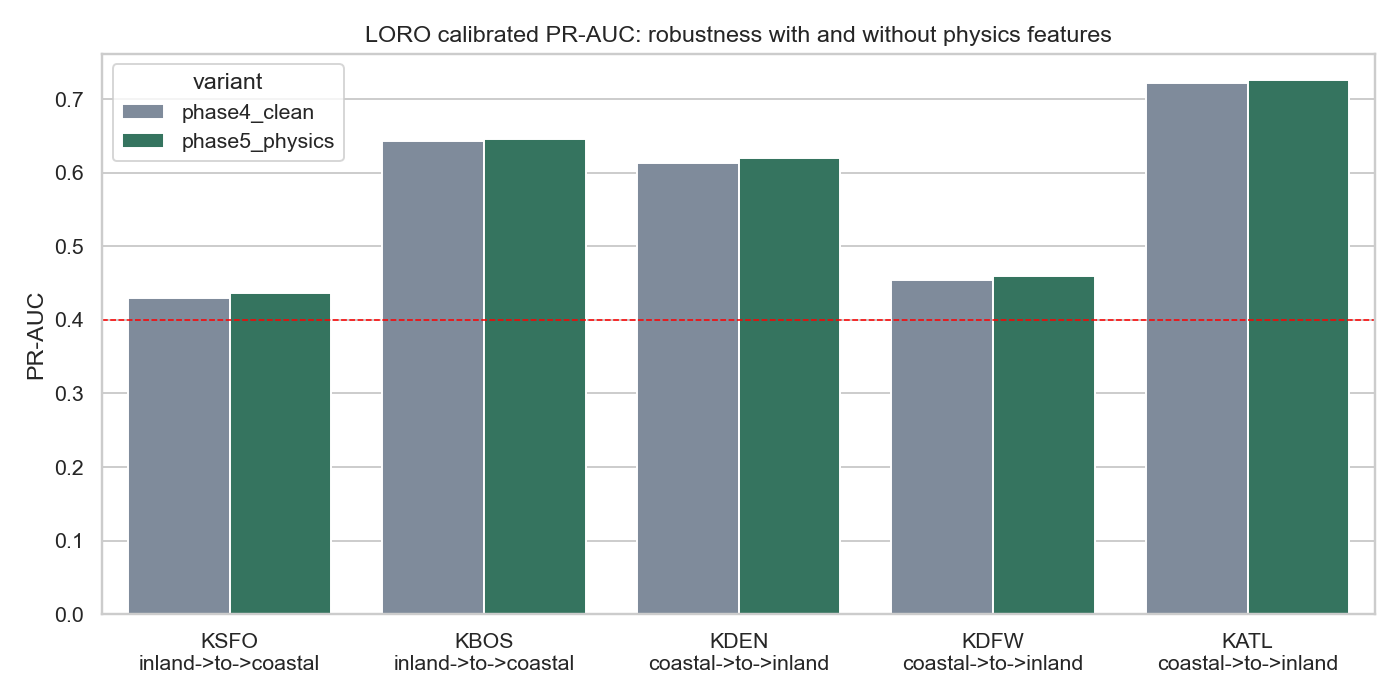

In [5]:
Image(filename=str(FIG / 'phase4_vs_phase5_loro_pr_auc.png'))


## Which Physics Features Actually Mattered


In [6]:
physics_df[['feature', 'gain', 'split']]


feature,gain,split
dew_depression_x_hour_sin,29001.640,139
dew_depression_min_6h,13183.242,44
pressure_drop_x_wind,10278.427,64
dew_depression_min_3h,4435.266,27
wind_dir_sin_coastal,4241.310,21
wind_dir_cos_coastal,1305.492,10
calm_and_saturated_coastal,689.184,7
calm_and_saturated,333.585,1


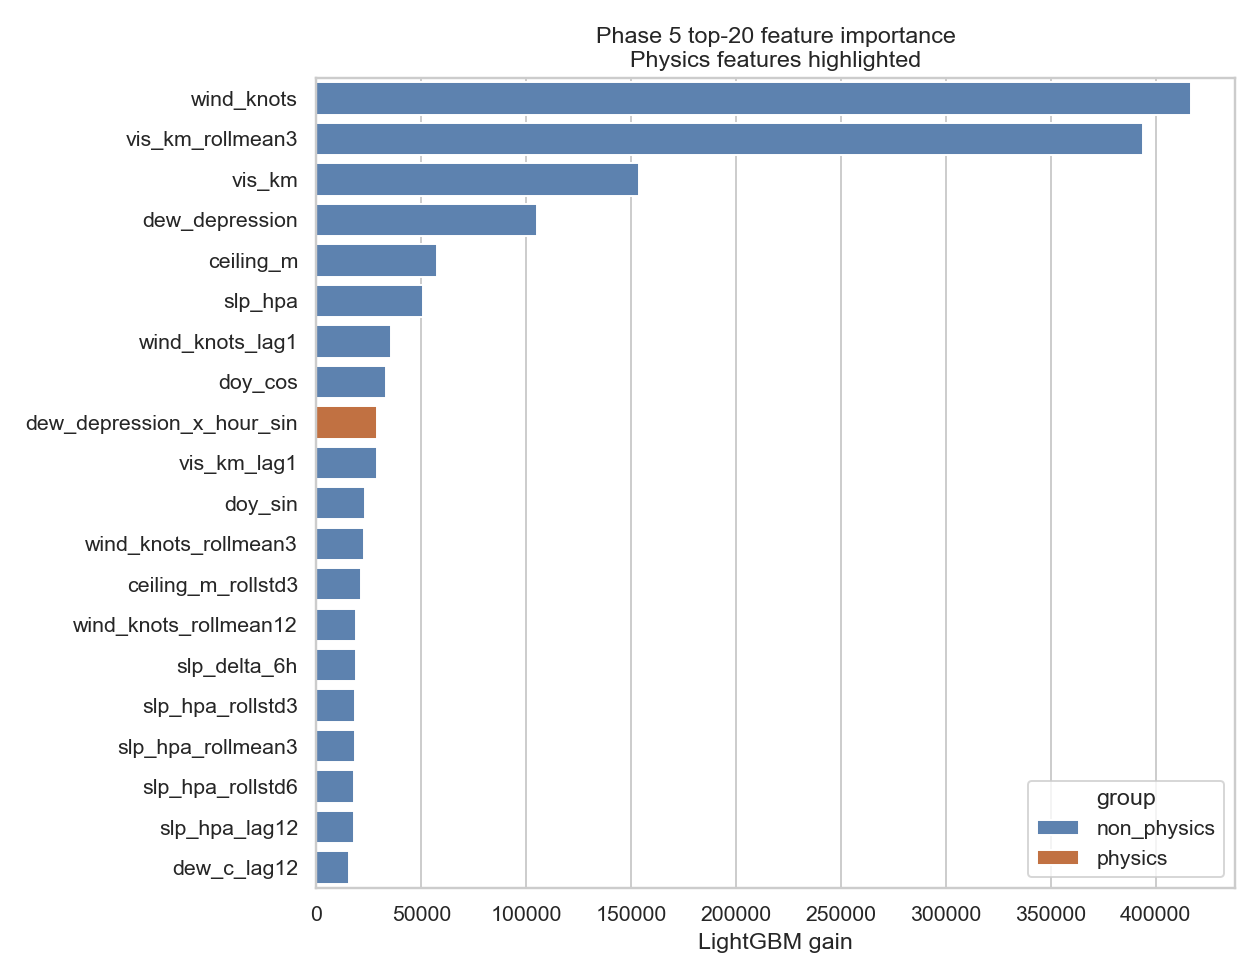

In [7]:
Image(filename=str(FIG / 'phase5_feature_importance_top20.png'))


## Reproducibility

To regenerate the underlying artifacts:

```bash
python -m src.features --variant phase4_clean
python -m src._feature_validate --variant phase4_clean
python -m src.baseline --variant phase4_clean
python -m src.features --variant phase5_physics
python -m src._feature_validate --variant phase5_physics
python -m src.baseline --variant phase5_physics
python -m src.compare_variants
```
